# Regime-Shift: Macro-Aware Tactical Asset Allocation Engine

This notebook runs the whole pipeline top to bottom:

**data → features → regime detection → optimization → backtest → results**

We detect hidden market regimes (Bull / Bear / Crisis) on Indian markets with a
Hidden Markov Model, then let the detected regime drive a convex portfolio
optimization across equities (Nifty 50), gold, and a liquid debt ETF. Everything
is validated **walk-forward** so no result depends on information from the
future.

The heavy lifting lives in the `src/` package; this notebook just narrates the
story and calls into it, so the notebook and `main.py` can never disagree.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # so `import src` works from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src import data as data_mod
from src import features as feature_mod
from src import regime as regime_mod
from src import backtest as backtest_mod
from src import optimize as optimize_mod
from src import metrics as metrics_mod
from src import plots as plot_mod

plt.rcParams["figure.figsize"] = (12, 4.5)
np.random.seed(config.RANDOM_SEED)
print("Ready.")

Ready.


## 1. Data

We pull daily prices for three asset classes traded on the NSE, plus the India
VIX as a fear gauge. Prices are cleaned for obvious bad ticks and converted to
log returns, all aligned on one shared calendar.

In [2]:
prices, returns, vix = data_mod.load_dataset()
returns.tail()

Cleaning prices...
  cleaned 2 bad tick(s) in GOLD: ['2019-12-19', '2019-12-20']
Final aligned dataset: 3680 trading days, 2010-01-05 -> 2024-12-30


,NIFTY,GOLD,BONDS
Date,,,
2024-12-23,0.007011,0.010213,0.00000
2024-12-24,-0.001087,-0.004544,-0.00001
2024-12-26,0.000950,0.005013,0.00001
2024-12-27,0.002658,0.003276,-0.00001
2024-12-30,-0.007101,-0.003276,0.00000


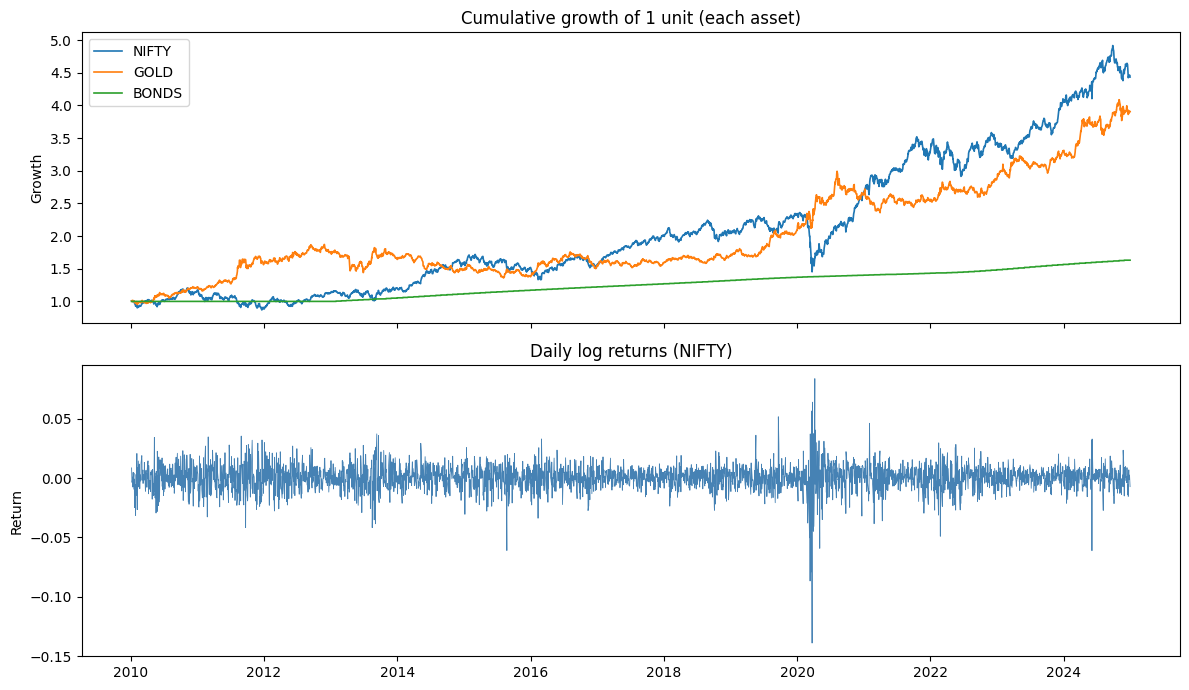

In [3]:
plot_mod.plot_asset_returns(prices, returns)

## 2. Features

We describe the market's state with momentum and volatility of the equity index
at a couple of horizons, plus the VIX level. These are the *raw* features; all
z-scoring happens later, inside the walk-forward loop, using training data only.

As a sanity check, the volatility feature should spike around known stress
periods (the 2020 COVID crash and the 2022 selloff).

Features: ['mom_21', 'mom_63', 'vol_21', 'vol_63', 'vix']


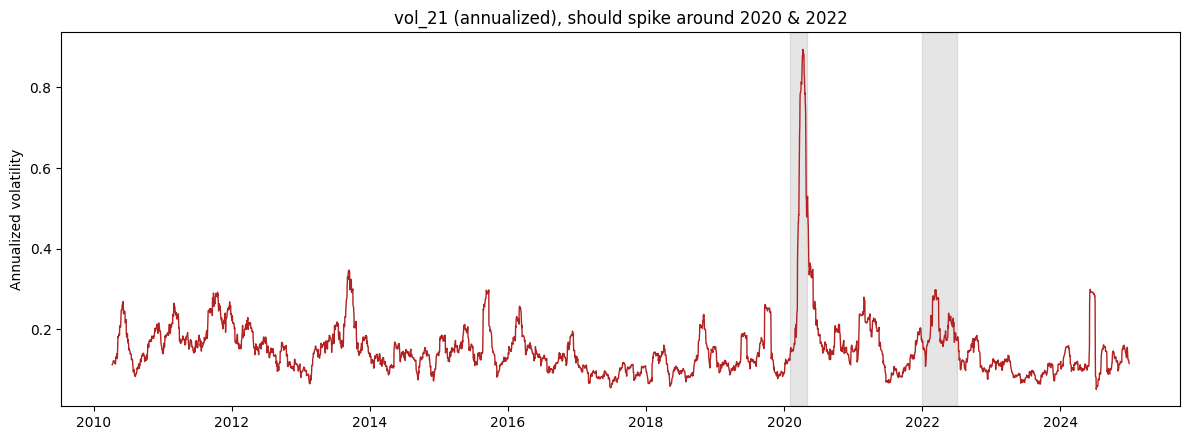

In [4]:
features = feature_mod.build_features(returns, vix)
print("Features:", list(features.columns))
plot_mod.plot_volatility_check(features)

## 3. Fitting the HMM (full-sample view)

First we fit one HMM on the whole sample just to *look* at the regimes and the
transition matrix. This is an in-sample picture for intuition only. The honest,
leak-free evaluation is the walk-forward backtest in Section 4.

The states come out unlabelled (0/1/2); we name them by average volatility:
calmest = Bull, most volatile = Crisis.

In [5]:
scaler = regime_mod.StandardScaler()
X_all = scaler.fit_transform(features.values)
vol_col = list(features.columns).index(feature_mod.volatility_feature_name())

full_model, full_label_map = regime_mod.fit_and_label(X_all, vol_col)
full_regimes = pd.Series(
    regime_mod.predict_regimes(full_model, full_label_map, X_all),
    index=features.index, name="regime")

# Put the transition matrix into Bull/Bear/Crisis order.
order = [None] * config.N_REGIMES
for state, name in full_label_map.items():
    order[regime_mod.REGIME_NAMES.index(name)] = state
ordered_transmat = full_model.transmat_[np.ix_(order, order)]

print("Regime day counts:")
print(full_regimes.value_counts(), "\n")
print("Transition matrix (Bull/Bear/Crisis):")
pd.DataFrame(ordered_transmat, index=regime_mod.REGIME_NAMES,
             columns=regime_mod.REGIME_NAMES).round(3)

Regime day counts:
regime
Bull      1680
Bear      1630
Crisis     307
Name: count, dtype: int64 

Transition matrix (Bull/Bear/Crisis):


,Bull,Bear,Crisis
Bull,0.990,0.010,0.000
Bear,0.011,0.985,0.004
Crisis,0.000,0.023,0.977


The high diagonal of the transition matrix confirms regimes are
"sticky": once the market is in a state it tends to stay there, which is
exactly what we expect. Now overlay the regimes on the Nifty price.

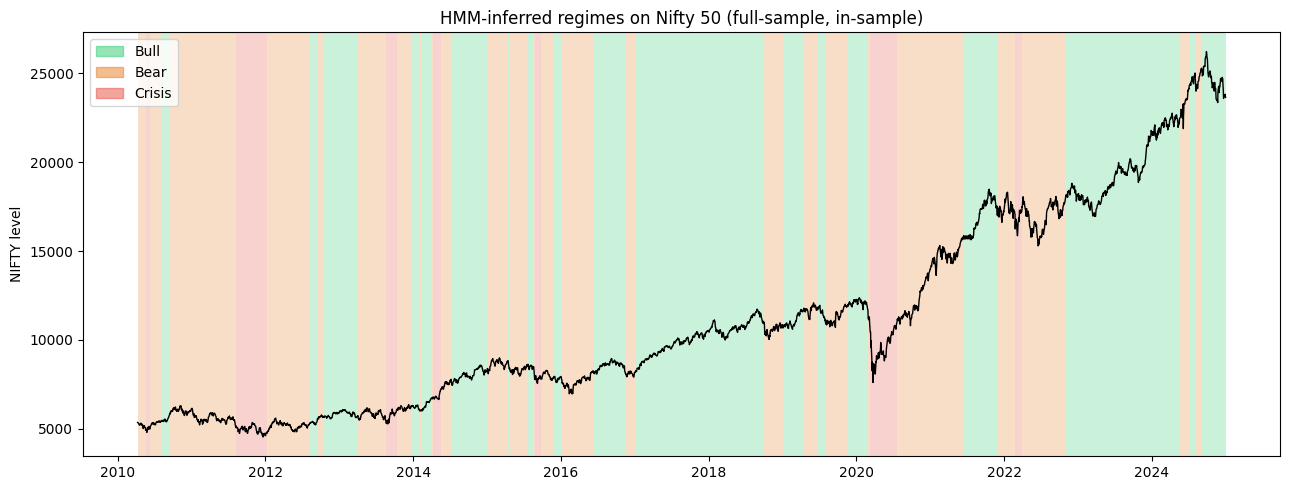

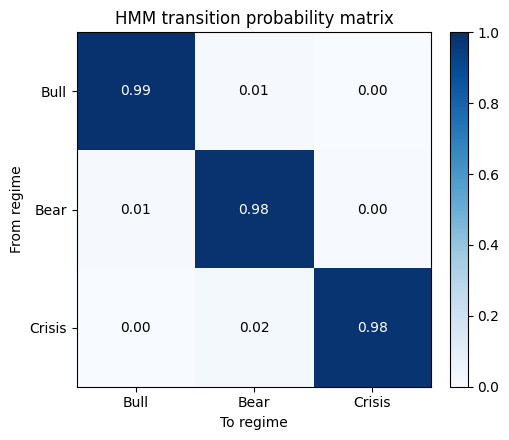

In [6]:
plot_mod.plot_regime_overlay(
    prices, full_regimes,
    title="HMM-inferred regimes on Nifty 50 (full-sample, in-sample)")
plot_mod.plot_transition_matrix(ordered_transmat)

## 4. Walk-forward validation

This is the part that keeps us honest. We slide expanding train/test windows
through time. In every fold we:

1. compute z-score stats on the **training** features only,
2. re-fit the HMM on that training window,
3. decode test-day regimes with a **causal forward filter** (each day uses only
   data up to that day (no lookahead),
4. estimate regime-conditional expected returns and a covariance from the
   **training** returns only,
5. solve one optimal portfolio per regime.

The result is an out-of-sample regime label and target weight for every day
after the first training window.

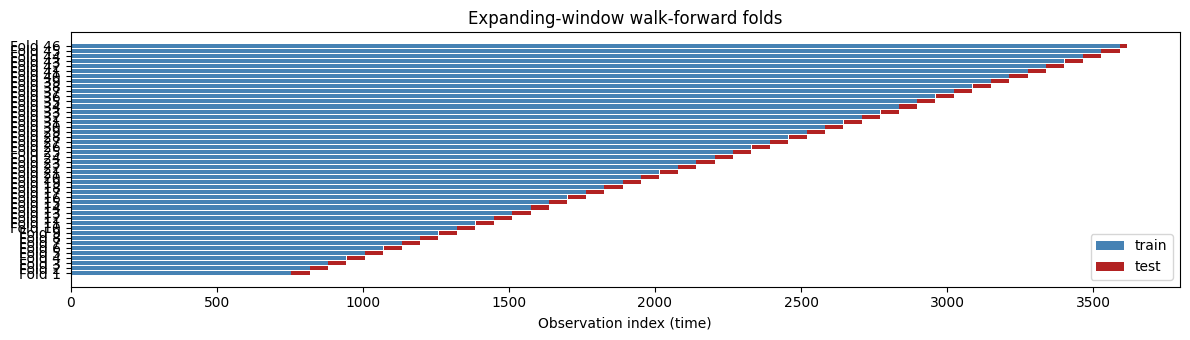

In [7]:
splits = backtest_mod.expanding_walk_forward_splits(
    len(features), config.MIN_TRAIN_SIZE, config.TEST_SIZE)
plot_mod.plot_walk_forward_folds(splits, features.index)

Walk-forward: 46 folds (min train 756d, test 63d each)


Out-of-sample regime counts:
Bull      1507
Bear       806
Crisis     548
Name: count, dtype: int64


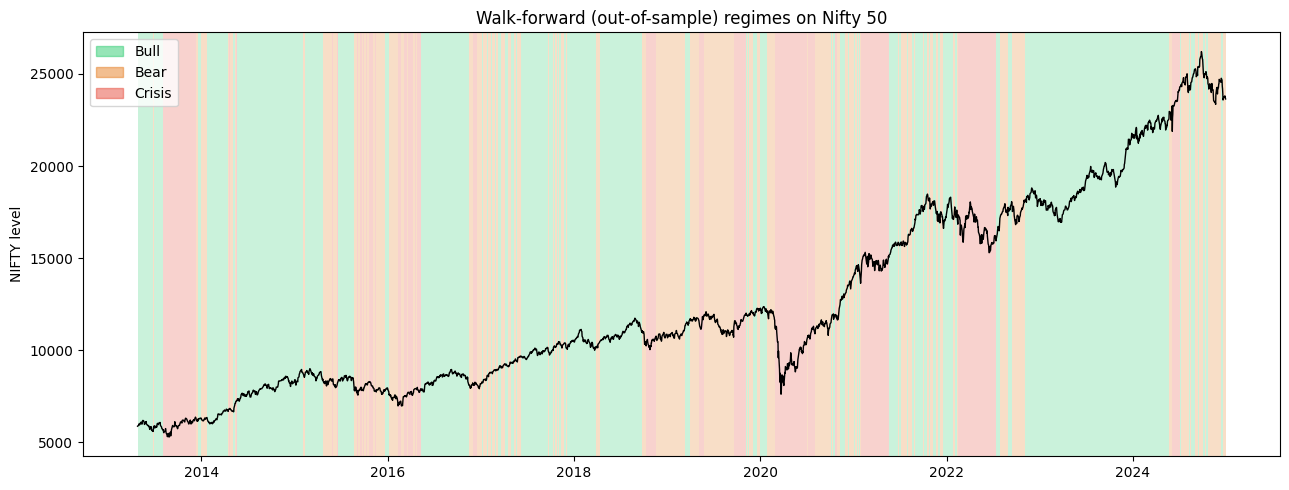

In [8]:
oos_regimes, target_weights = backtest_mod.run_walk_forward(features, returns)
print("Out-of-sample regime counts:")
print(oos_regimes.value_counts())
plot_mod.plot_regime_overlay(
    prices, oos_regimes,
    title="Walk-forward (out-of-sample) regimes on Nifty 50")

### What does each regime actually hold?

The average out-of-sample weights show the strategy behaving sensibly: heavy in
equities when calm (Bull), defensive and gold-tilted in Bear, and parked in the
safe asset during Crisis.

In [9]:
avg = target_weights.copy()
avg["regime"] = oos_regimes
avg.groupby("regime").mean().round(3)

,NIFTY,GOLD,BONDS
regime,,,
Bear,0.180,0.238,0.582
Bull,0.519,0.172,0.309
Crisis,0.171,0.229,0.600


## 5. Backtest vs static benchmarks

We compare the dynamic regime-switching strategy against a static 60/40
(equity/bonds) portfolio and an equal-weight portfolio. All three rebalance on
the same monthly schedule, and we charge a transaction cost on turnover so the
comparison is fair. We report the dynamic strategy both gross and net of
costs.

In [10]:
freq = config.REBALANCE_FREQUENCY
simple_returns = np.expm1(returns[list(config.ASSET_TICKERS.keys())])
oos_index = target_weights.index

dyn_gross, dyn_net, dyn_turn = backtest_mod.simulate(
    target_weights, simple_returns, config.TRANSACTION_COST_BPS, freq)
dyn_gross_only, _, _ = backtest_mod.simulate(target_weights, simple_returns, 0, freq)

bench_6040_w = backtest_mod.static_weight_schedule(config.BENCHMARK_60_40, oos_index)
bench_eq_w = backtest_mod.static_weight_schedule(config.BENCHMARK_EQUAL, oos_index)
_, bench_6040_net, bench_6040_turn = backtest_mod.simulate(
    bench_6040_w, simple_returns, config.TRANSACTION_COST_BPS, freq)
_, bench_eq_net, bench_eq_turn = backtest_mod.simulate(
    bench_eq_w, simple_returns, config.TRANSACTION_COST_BPS, freq)
print("Backtest done.")

Backtest done.


### Performance summary (net of transaction costs)

In [11]:
net_table = metrics_mod.summary_table({
    "Dynamic (net)": (dyn_net, dyn_turn),
    "Static 60/40": (bench_6040_net, bench_6040_turn),
    "Equal weight": (bench_eq_net, bench_eq_turn),
})
net_table.round(3)

,Ann. Return,Ann. Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Ann. Turnover
Dynamic (net),0.061,0.065,0.940,1.235,-0.134,0.454,3.890
Static 60/40,0.096,0.098,0.982,1.229,-0.237,0.406,0.291
Equal weight,0.090,0.066,1.333,1.799,-0.152,0.592,0.359


### How much do transaction costs matter?

In [12]:
metrics_mod.summary_table({
    "Dynamic (gross)": (dyn_gross_only, dyn_turn),
    "Dynamic (net of costs)": (dyn_net, dyn_turn),
}).round(3)

,Ann. Return,Ann. Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Ann. Turnover
Dynamic (gross),0.065,0.065,0.999,1.313,-0.130,0.498,3.89
Dynamic (net of costs),0.061,0.065,0.940,1.235,-0.134,0.454,3.89


### Equity curves and drawdowns

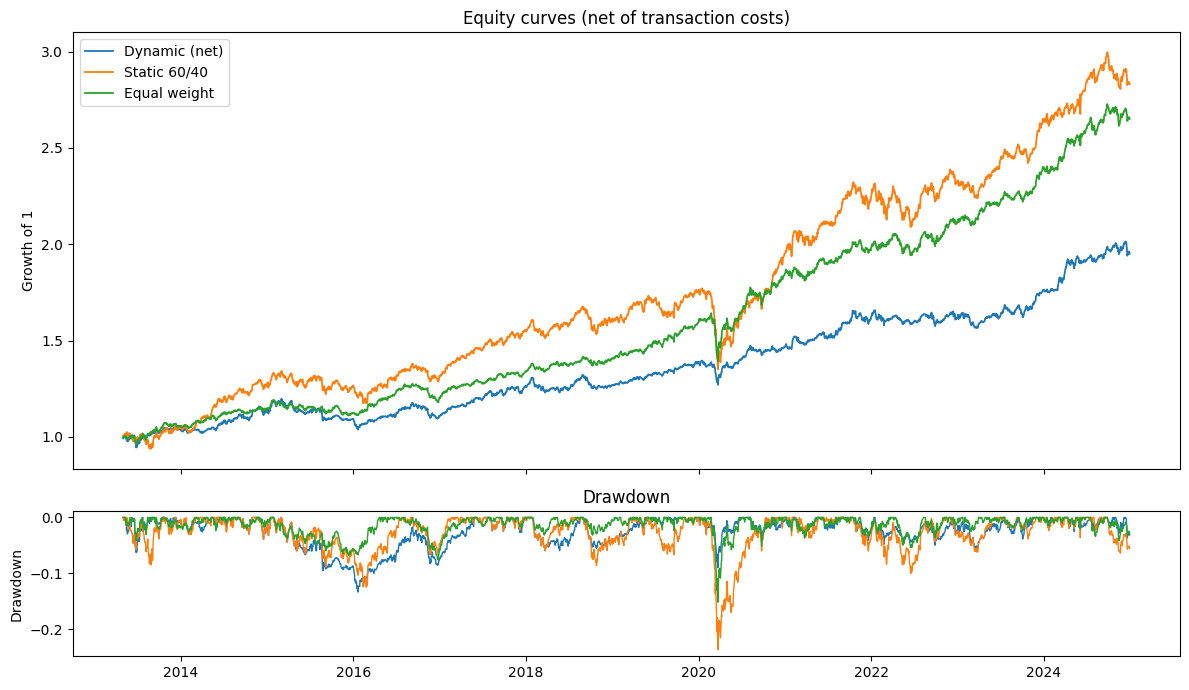

In [13]:
plot_mod.plot_equity_curves({
    "Dynamic (net)": dyn_net,
    "Static 60/40": bench_6040_net,
    "Equal weight": bench_eq_net,
})

## 6. Takeaways

- The HMM cleanly separates calm, choppy, and crisis markets with no hand
  labelling, and the Crisis band lines up with the 2020 COVID crash.
- Re-fitting inside each walk-forward fold, causal filtering, and train-only
  scaling mean every regime label depends only on the past.
- The dynamic strategy's headline result is **downside protection**: its worst
  drawdown is far shallower than the 60/40 portfolio's, at comparable
  risk-adjusted return, precisely because it de-risks into the safe asset when
  the HMM flags a crisis.
- Transaction costs are modest here (monthly rebalancing keeps turnover low),
  but the with/without-cost comparison shows why a noisier, daily-rebalanced
  version would bleed returns.

See the `README.md` for the reasoning behind the key design choices.